# AEVB — Plots depuis checkpoints
Charge les modèles depuis `results/checkpoints/` et génère toutes les figures.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LATENT_DIMS = [2, 5, 10, 20]

BASE        = Path(r'C:\Users\arist\Documents\Cours_Eurecom\Semestre 2, 2A\ASI\Project\Project ASI')
CKPT_DIR    = BASE / 'results' / 'checkpoints'
FIGURES_DIR = BASE / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device : {DEVICE}')
print('Checkpoints disponibles :')
for f in sorted(CKPT_DIR.glob('*.pt')):
    print(f'  {f.name}')

Device : cpu
Checkpoints disponibles :
  vae_freyface_nz10.pt
  vae_freyface_nz2.pt
  vae_freyface_nz20.pt
  vae_freyface_nz5.pt
  vae_mnist_nz10.pt
  vae_mnist_nz2.pt
  vae_mnist_nz20.pt
  vae_mnist_nz5.pt
  ws_freyface_nz10.pt
  ws_freyface_nz2.pt
  ws_freyface_nz20.pt
  ws_freyface_nz5.pt
  ws_mnist_nz10.pt
  ws_mnist_nz2.pt
  ws_mnist_nz20.pt
  ws_mnist_nz5.pt


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
    def forward(self, x):
        h = torch.tanh(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

class BernoulliDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    def forward(self, z):
        return torch.sigmoid(self.fc2(torch.tanh(self.fc1(z))))

class GaussianDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, output_dim)
        self.fc_logvar = nn.Linear(hidden_dim, output_dim)
    def forward(self, z):
        h = torch.tanh(self.fc1(z))
        return torch.sigmoid(self.fc_mu(h)), self.fc_logvar(h)

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, decoder_type='bernoulli'):
        super().__init__()
        self.latent_dim   = latent_dim
        self.decoder_type = decoder_type
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = BernoulliDecoder(latent_dim, hidden_dim, input_dim) if decoder_type == 'bernoulli' \
                  else GaussianDecoder(latent_dim, hidden_dim, input_dim)
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decoder(z), mu, logvar

In [3]:
class WakeSleepModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, decoder_type='bernoulli'):
        super().__init__()
        self.latent_dim   = latent_dim
        self.decoder_type = decoder_type
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = BernoulliDecoder(latent_dim, hidden_dim, input_dim) if decoder_type == 'bernoulli' \
                  else GaussianDecoder(latent_dim, hidden_dim, input_dim)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)


In [4]:
def load_checkpoint(path, input_dim, hidden_dim):
    ckpt  = torch.load(path, map_location=DEVICE, weights_only=False)
    model = VAE(input_dim, hidden_dim, ckpt['latent_dim'], ckpt['decoder_type']).to(DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    print(f'  Loaded <- {path.name}')
    return {'model': model, 'train': ckpt['train_elbos'], 'test': ckpt['test_elbos']}

def load_checkpoint_ws(path, input_dim, hidden_dim):
    ckpt  = torch.load(path, map_location=DEVICE, weights_only=False)
    model = WakeSleepModel(input_dim, hidden_dim, ckpt['latent_dim'], ckpt['decoder_type']).to(DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    print(f'  Loaded <- {path.name}')
    return {'model': model, 'train': ckpt['train_elbos'], 'test': ckpt['test_elbos']}


results_mnist = {}
for nz in LATENT_DIMS:
    path = CKPT_DIR / f'vae_mnist_nz{nz}.pt'
    if path.exists(): results_mnist[nz] = load_checkpoint(path, 784, 500)
    else: print(f'  [!] Manquant : {path.name}')

results_ff = {}
for nz in LATENT_DIMS:
    path = CKPT_DIR / f'vae_freyface_nz{nz}.pt'
    if path.exists(): results_ff[nz] = load_checkpoint(path, 560, 200)
    else: print(f'  [!] Manquant : {path.name}')

print(f'\nMNIST    : {list(results_mnist.keys())}')
print(f'FreyFace : {list(results_ff.keys())}')

results_ws_mnist = {}
for nz in LATENT_DIMS:
    path = CKPT_DIR / f'ws_mnist_nz{nz}.pt'
    if path.exists(): results_ws_mnist[nz] = load_checkpoint_ws(path, 784, 500)
    else: print(f'  [!] Manquant : {path.name}')

results_ws_ff = {}
for nz in LATENT_DIMS:
    path = CKPT_DIR / f'ws_freyface_nz{nz}.pt'
    if path.exists(): results_ws_ff[nz] = load_checkpoint_ws(path, 560, 200)
    else: print(f'  [!] Manquant : {path.name}')


  Loaded <- vae_mnist_nz2.pt
  Loaded <- vae_mnist_nz5.pt
  Loaded <- vae_mnist_nz10.pt
  Loaded <- vae_mnist_nz20.pt
  Loaded <- vae_freyface_nz2.pt
  Loaded <- vae_freyface_nz5.pt
  Loaded <- vae_freyface_nz10.pt
  Loaded <- vae_freyface_nz20.pt

MNIST    : [2, 5, 10, 20]
FreyFace : [2, 5, 10, 20]
  Loaded <- ws_mnist_nz2.pt
  Loaded <- ws_mnist_nz5.pt
  Loaded <- ws_mnist_nz10.pt
  Loaded <- ws_mnist_nz20.pt
  Loaded <- ws_freyface_nz2.pt
  Loaded <- ws_freyface_nz5.pt
  Loaded <- ws_freyface_nz10.pt
  Loaded <- ws_freyface_nz20.pt


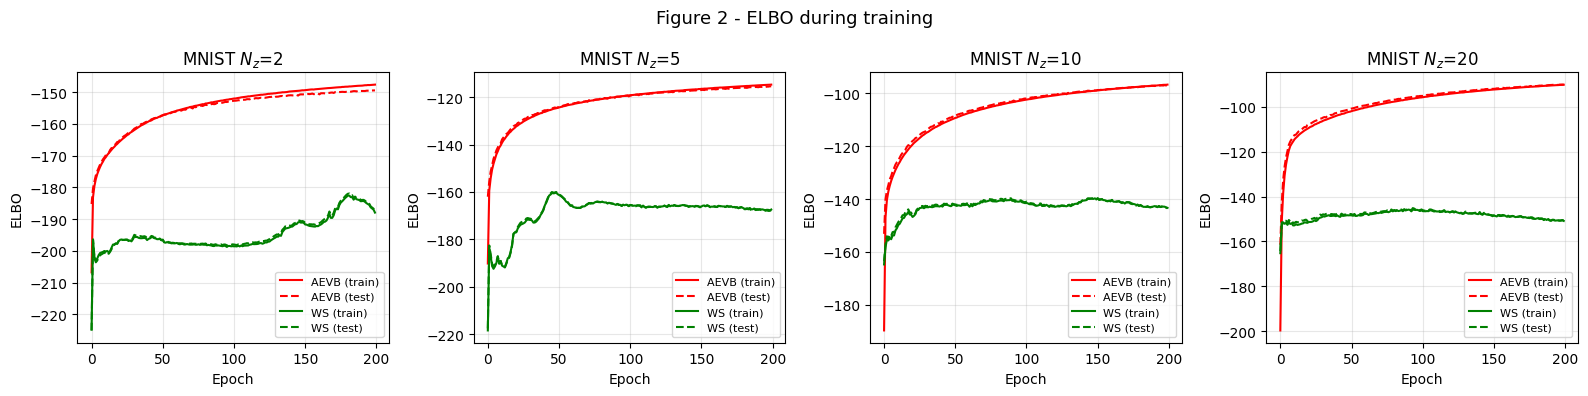

In [5]:
# Figure 2 - ELBO MNIST
if results_mnist:
    fig, axes = plt.subplots(1, len(results_mnist), figsize=(4 * len(results_mnist), 4))
    for ax, nz in zip(axes, sorted(results_mnist)):
        res = results_mnist[nz]
        ws = results_ws_mnist.get(nz, None)
        ax.plot(res['train'], 'r-',  label='AEVB (train)', linewidth=1.5)
        ax.plot(res['test'],  'r--', label='AEVB (test)',  linewidth=1.5)
        if ws:
            ax.plot(ws['train'], color='green', linestyle='-',  label='WS (train)', linewidth=1.5)
            ax.plot(ws['test'],  color='green', linestyle='--', label='WS (test)',  linewidth=1.5)
        ax.set_title(f'MNIST $N_z$={nz}'); ax.set_xlabel('Epoch'); ax.set_ylabel('ELBO')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.suptitle('Figure 2 - ELBO during training', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig2_elbo_mnist.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


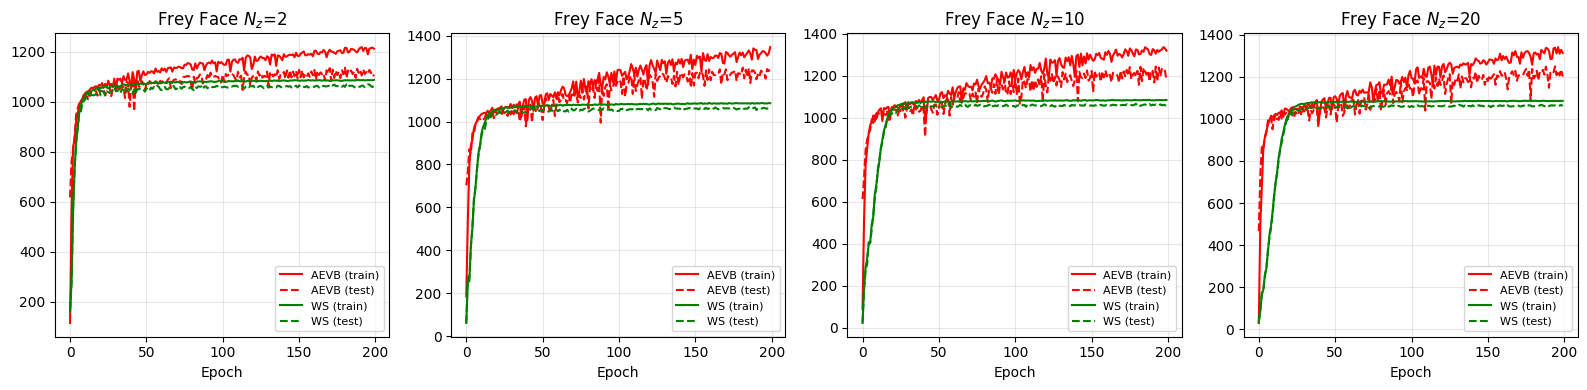

In [6]:
# Figure 2 - ELBO Frey Face
if results_ff:
    fig, axes = plt.subplots(1, len(results_ff), figsize=(4 * len(results_ff), 4))
    for ax, nz in zip(axes, sorted(results_ff)):
        res = results_ff[nz]
        ws = results_ws_ff.get(nz, None)
        ax.plot(res['train'], 'r-',  label='AEVB (train)', linewidth=1.5)
        ax.plot(res['test'],  'r--', label='AEVB (test)',  linewidth=1.5)
        if ws:
            ax.plot(ws['train'], color='green', linestyle='-',  label='WS (train)', linewidth=1.5)
            ax.plot(ws['test'],  color='green', linestyle='--', label='WS (test)',  linewidth=1.5)
        ax.set_title(f'Frey Face $N_z$={nz}'); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig2_elbo_freyface.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


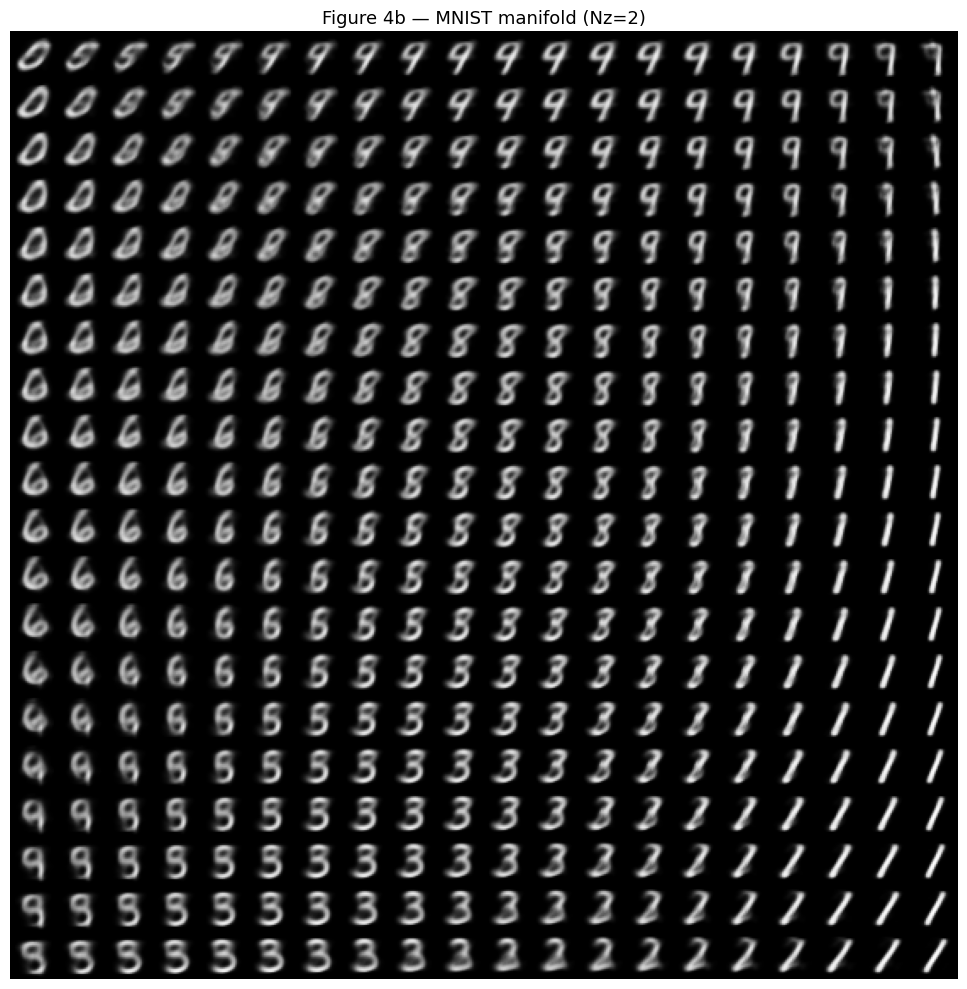

In [7]:
# Figure 4 — Manifold MNIST (Nz=2)
if 2 in results_mnist:
    model_2d = results_mnist[2]['model']
    GRID_N = 20
    grid_x = norm.ppf(np.linspace(0.05, 0.95, GRID_N))
    grid_y = norm.ppf(np.linspace(0.05, 0.95, GRID_N))
    canvas = np.zeros((28 * GRID_N, 28 * GRID_N))
    with torch.no_grad():
        for i, yi in enumerate(grid_y[::-1]):
            for j, xi in enumerate(grid_x):
                z = torch.tensor([[xi, yi]], dtype=torch.float32).to(DEVICE)
                canvas[i*28:(i+1)*28, j*28:(j+1)*28] = model_2d.decoder(z).cpu().numpy().reshape(28, 28)
    plt.figure(figsize=(10, 10))
    plt.imshow(canvas, cmap='gray'); plt.axis('off')
    plt.title('Figure 4b — MNIST manifold (Nz=2)', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig4_mnist_manifold.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

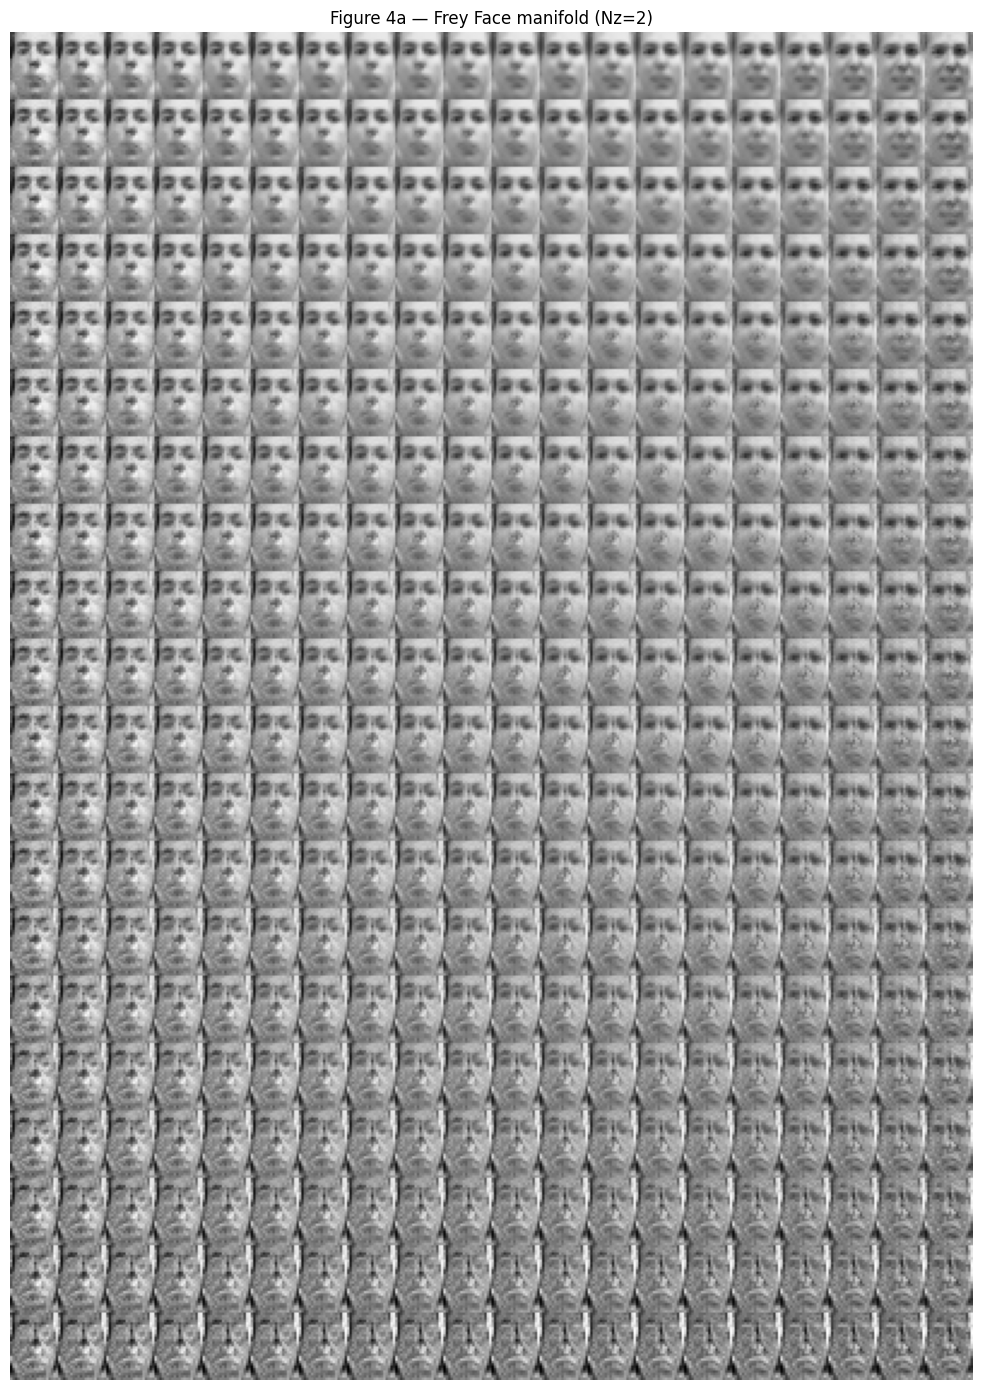

In [8]:
# Figure 4 — Manifold Frey Face (Nz=2)
if 2 in results_ff:
    model_ff_2d = results_ff[2]['model']
    GRID_N = 20
    grid_x = norm.ppf(np.linspace(0.05, 0.95, GRID_N))
    grid_y = norm.ppf(np.linspace(0.05, 0.95, GRID_N))
    H, W = 28, 20
    canvas_ff = np.zeros((H * GRID_N, W * GRID_N))
    with torch.no_grad():
        for i, yi in enumerate(grid_y[::-1]):
            for j, xi in enumerate(grid_x):
                z = torch.tensor([[xi, yi]], dtype=torch.float32).to(DEVICE)
                mu_img, _ = model_ff_2d.decoder(z)
                canvas_ff[i*H:(i+1)*H, j*W:(j+1)*W] = mu_img.cpu().numpy().reshape(H, W)
    plt.figure(figsize=(10, 14))
    plt.imshow(canvas_ff, cmap='gray'); plt.axis('off')
    plt.title('Figure 4a — Frey Face manifold (Nz=2)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig4_freyface_manifold.png', dpi=150)
    plt.show(); plt.close()

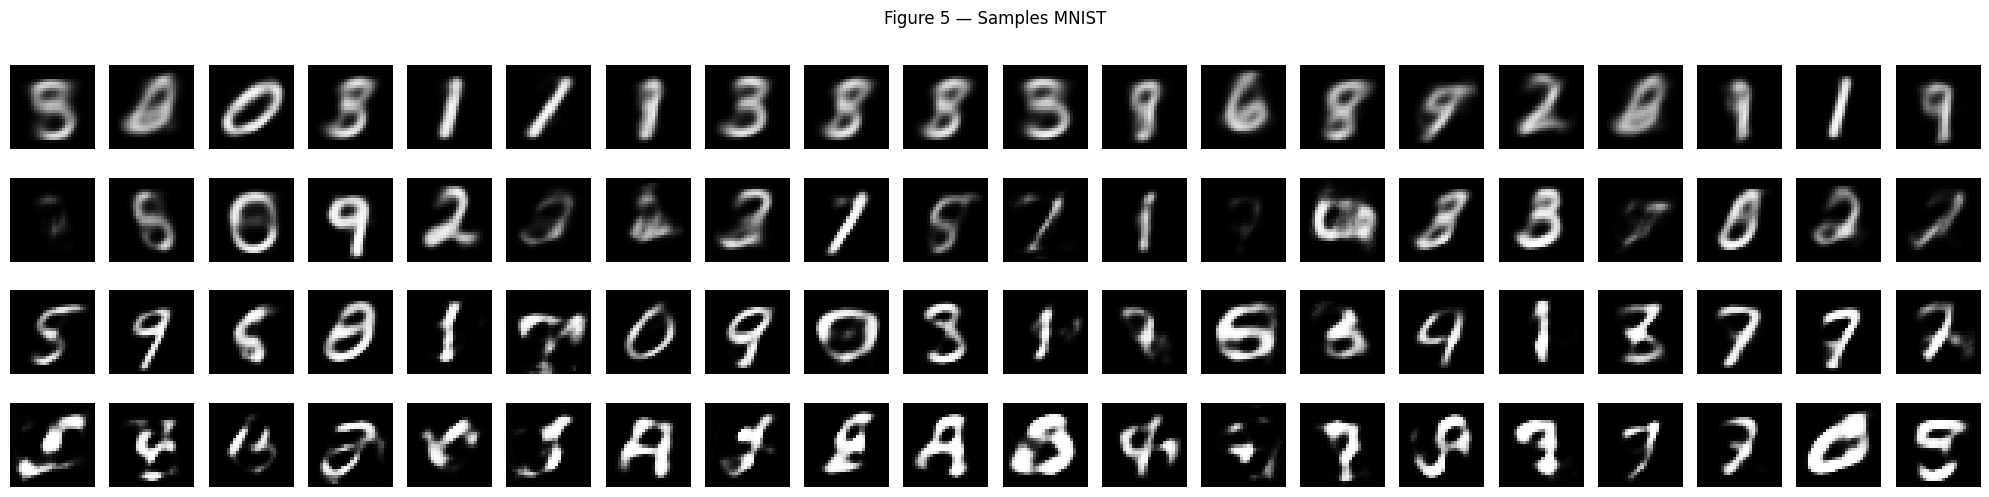

In [9]:
# Figure 5 — Samples MNIST
if results_mnist:
    N_SAMPLES = 20
    fig, axes = plt.subplots(len(results_mnist), N_SAMPLES,
                             figsize=(N_SAMPLES, len(results_mnist) * 1.3))
    for row, nz in enumerate(sorted(results_mnist)):
        with torch.no_grad():
            samples = results_mnist[nz]['model'].decoder(
                torch.randn(N_SAMPLES, nz).to(DEVICE)).cpu().numpy()
        for col in range(N_SAMPLES):
            axes[row, col].imshow(samples[col].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(f'$N_z$={nz}', fontsize=10)
    plt.suptitle('Figure 5 — Samples MNIST', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig5_samples.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()